## TODO:  HEADER

In [1]:
%load_ext autoreload
%autoreload 2

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocess import text_cleaner, pipeline
from lingua import LanguageDetectorBuilder
from deep_translator import GoogleTranslator
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# EDA

In [2]:
train_full = pd.read_csv(r"data/train.csv")
train, validation = train_test_split(train_full, test_size=0.2, stratify=train_full.label)
test = pd.read_csv(r"data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
9006,Boeing’s stock is headed for its 12th decline ...,0
3137,Keystone leak affected 10x more land than thou...,2
2626,Ark Restaurants : Announces Financial Results ...,2


,text,label
2580,$PIPR - Piper Sandler Companies (PIPR) CEO Cha...,2
2547,$KLBAY - Klabin S.A. (KLBAY) CEO Cristiano Tei...,2
3838,"India Online Test Preparation Markets, 2020-20...",1


,text
id,
1580,Jason Garrett’s job security in picture form h...
2225,Amen Properties Reports Results for Third Quar...
966,Auto parts supplier Prevent sues Volkswagen fo...


## general

In [3]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,Boeing mulls trimming or suspending 737 MAX pr...
freq,1


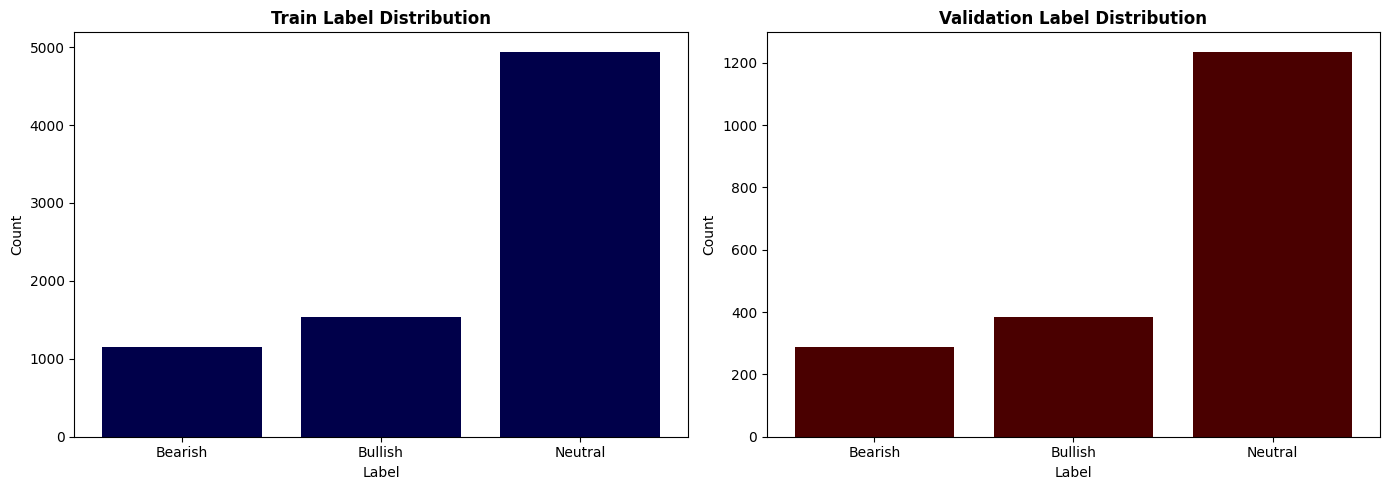

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=train.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#00004A",
        )

ax[1].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=validation.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#4A0000",
        )

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title(
    "Train Label Distribution", fontweight="bold"
)

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title(
    "Validation Label Distribution", fontweight="bold"
)

plt.tight_layout()
plt.savefig(r"plots/correct_split.png")
plt.show()

## Text Overview

### Raw

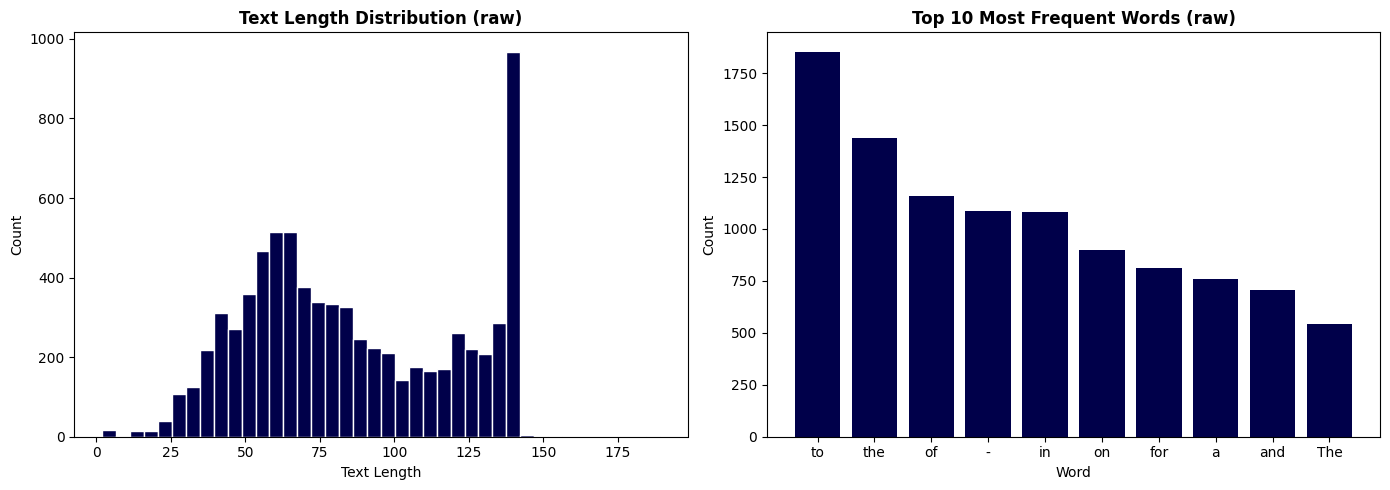

In [5]:
freq_raw = pd.Series(' '.join(train['text']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(
         train.text.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

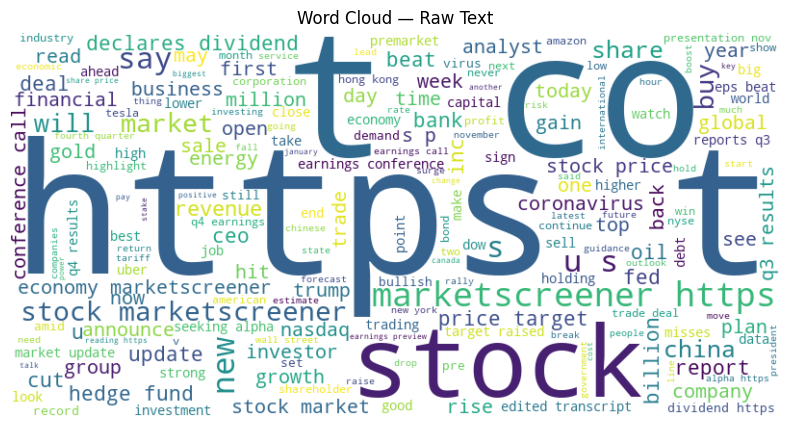

In [6]:
raw_text = ' '.join(train['text']).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### Cleaning

In [7]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
8071,RECAP 12/10 Unusual Calls:\n$QSR Dec 67.5 C\n$...,1,recap 12 10 unusual calls STOCK dec 67 5 c STO...
2464,$LULU - Market Expects Good Earnings For Lulul...,1,STOCK market expects good earnings for lululem...
4604,Highlight: “It will be the first insulin pill ...,2,highlight it will be the first insulin pill in...
91,Needham's Martin Defends Her Prediction That N...,0,needham martin defends her prediction that net...
368,CA$10.60 - That's What Analysts Think Vecima N...,2,ca 10 60 that is what analysts think vecima ne...


,text,label,text_clean
676,The ECB will accept junk-rated Greek governmen...,2,the ecb will accept junk rated greek governmen...
1143,$REGN - Regeneron Pharmaceuticals (REGN) Prese...,2,STOCK regeneron pharmaceuticals regn presents ...
3450,General Motors' Q4 Profit Beat Estimates Despi...,1,general motors q4 profit beat estimates despit...
4483,From black swan to bubble: investors weigh cor...,2,from black swan to bubble investors weigh coro...
8663,Is Corporacion America Airports SA (CAAP) A Go...,2,is corporacion america airports sa caap a good...


In [8]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [lang.name.lower() if lang else None for lang in languages_train]

languages_validation = detector.detect_languages_in_parallel_of(validation.text_clean)
validation["language"] = [lang.name.lower() if lang else None for lang in languages_validation]

non_eng_train = train[train["language"]!="english"]["text_clean"].index.to_list()
non_eng_validation = validation[validation["language"]!="english"]["text_clean"].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
4752,It's Getting Harder to Make Money Flipping Houses,2,it is getting harder to make money flipping ho...,english
6034,Fidelity National to buy FGL Holdings in diver...,2,fidelity national to buy fgl holdings in diver...,english
696,The Federal Reserve assured the nation that th...,2,the federal reserve assured the nation that th...,english
5075,"Singapore Raises Virus Response Level, Now on ...",2,singapore raises virus response level now on p...,english
962,Coca-Cola Breaks Down a Record Quarter,1,coca cola breaks down a record quarter,english


In [9]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
                                        )
            )
    ).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
                                        )
            )
    ).to_list()

In [10]:
# TODO: change stopwords as Bea said
train["text_tokens"] = pipeline(train["text_clean"], to_clean=False)
validation["text_tokens"] = pipeline(validation["text_clean"], to_clean=False)

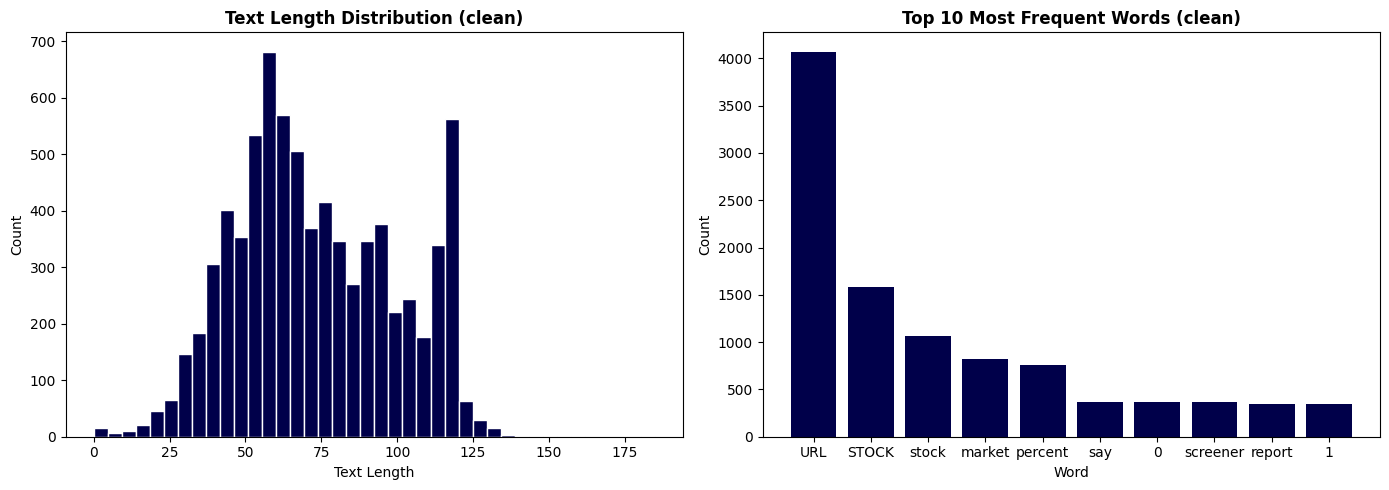

In [11]:
train["text_clean_joined"] = train['text_tokens'].apply(lambda x: " ".join(x))
freq_clean = pd.Series(' '.join(train['text_clean_joined']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
         train.text_clean.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )
ax[1].bar(freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

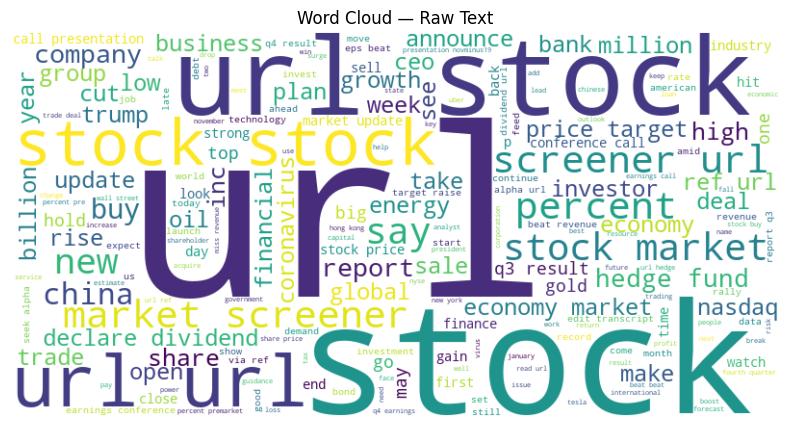

In [12]:
raw_text = ' '.join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()